# 03 – Random Forest: Ensemblemodell med Bagging

## Vad är en Random Forest?
Tänk dig att du ska gissa hur många godisbitar det finns i en burk.
Om du frågar **en person** kan de ha fel.
Men om du frågar **100 personer** och tar genomsnittet – då blir svaret mycket bättre!

Det är precis vad en **Random Forest** gör:
- Den bygger **många beslutsträd** (t.ex. 200 stycken)
- Varje träd tränas på en **slumpmässig del** av datan
- Varje träd röstar: "Stannar" eller "Slutar"
- Det svar som **flest träd röstar på** vinner

Det här kallas **Bagging** (Bootstrap AGGregatING).

## Varför är det bättre än ett enda träd?
Ett enda beslutsträd är som en person som memorerar alla svar –
det funkar perfekt på träningsdatan men misslyckas på ny data (**overfitting**).

Random Forest löser det genom att varje träd ser olika data och olika features –
tillsammans täcker de in helheten mycket bättre.

## Vad gör vi i denna notebook?
1. Laddar och förbereder datan (samma som i notebook 02)
2. Tränar en **standard Random Forest** (snabb referens)
3. Finjusterar hyperparametrar med **GridSearchCV**
4. Utvärderar med F1, ROC-AUC och Recall
5. Plottar Feature Importance och Permutation Importance
6. Sparar resultat till `outputs/`

In [1]:
# ── Imports ────────────────────────────────────────────────────────────────────
import sys
import os

os.chdir("..")          # sätt projektroten som arbetskatalog
sys.path.append(".")    # så att Python hittar src/

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_processing import load_raw, clean_and_encode, split_and_scale
from src.model_training import train_random_forest, tune_random_forest
from src.evaluation import (
    evaluate_model,
    plot_confusion_matrix,
    plot_roc_curve,
    plot_feature_importance,
    plot_permutation_importance,
)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (10, 5)})

os.makedirs("outputs/figures", exist_ok=True)
os.makedirs("outputs/results", exist_ok=True)

print(f"✅ Arbetskatalog: {os.getcwd()}")
print("✅ Allt importerat och redo!")

✅ Arbetskatalog: c:\Users\anoth\dev\AIkurs-statistik\ensemble-attrition-ml
✅ Allt importerat och redo!


## Steg 1 – Ladda och förbered datan

Precis som i de tidigare notebooks laddar vi rådata, rensar den och delar upp den i tränings- och testset.

Vi använder samma funktioner från `src/data_processing.py` – så allt är konsekvent genom hela projektet.

In [2]:
# ── Ladda förberedd data ───────────────────────────────────────────────────────
CLEAN_PATH = "data/attrition_clean.csv"

df_clean = pd.read_csv(CLEAN_PATH)

X_train, X_test, y_train, y_test = split_and_scale(df_clean)

print(f"\nTräningsset : {X_train.shape[0]} rader, {X_train.shape[1]} features")
print(f"Testset     : {X_test.shape[0]} rader, {X_test.shape[1]} features")
print(f"\nFördelning i träningsset:\n{y_train.value_counts().to_string()}")

[data_processing] Split: 1,176 train / 294 test (stratified, test_size=0.2)

Träningsset : 1176 rader, 44 features
Testset     : 294 rader, 44 features

Fördelning i träningsset:
Attrition
0    986
1    190


## Steg 2 – Standard Random Forest (ingen tuning)

Innan vi finjusterar hyperparametrar tränar vi en **standard Random Forest**
med defaultvärden – som en snabb referens.

Det är som att baka en kaka utan recept först,
så att vi vet hur mycket bättre det blir när vi följer receptet noggrant.

In [3]:
# ── Standard Random Forest ─────────────────────────────────────────────────────
rf_default = train_random_forest(X_train, y_train)
results_default = evaluate_model(rf_default, X_test, y_test, model_name="random_forest_default")

[model_training] Training Random Forest with params: {'n_estimators': 200, 'class_weight': 'balanced', 'n_jobs': -1, 'random_state': 42}
[model_training] Random Forest training complete.
[evaluation] random_forest_default | F1: 0.1429 | ROC-AUC: 0.7707
[evaluation] Results saved to: outputs/results\random_forest_default.json


## Vad vi ser? – Standard Random Forest

| Metric  | Värde |
|---------|-------|
| F1-score | 0.1429 |
| ROC-AUC  | 0.7707 |

**F1-score: 0.14 – varför så lågt?**
F1 mäter balansen mellan att hitta rätt personer (Recall)
och att inte peka ut fel personer (Precision).

0.14 är väldigt lågt – modellen är försiktig och missar många
anställda som faktiskt är på väg att sluta.

**ROC-AUC: 0.77 – faktiskt ganska bra!**
ROC-AUC mäter hur bra modellen *rangordnar* risk.
0.77 betyder att modellen i 77% av fallen rankar en person
som slutar högre än en som stannar – det är lovande.

**Varför skiljer sig F1 och ROC-AUC så mycket?**
Modellen hittar rätt riskpersoner i sin ranking (bra AUC),
men när den tvingas välja "Ja eller Nej" vid 50%-gränsen
blir den för försiktig och säger nästan alltid "Stannar".

➡️ Det är precis detta GridSearchCV ska fixa i nästa steg!

## Steg 3 – Finjustera med GridSearchCV

Nu ska vi hitta de **bästa inställningarna** för vår Random Forest.

Tänk dig att du bakar pizza och kan välja:
- Ugnstemperatur: 200°, 225° eller 250°
- Tid: 10, 15 eller 20 minuter
- Tjocklek på degen: tunn, mellan eller tjock

GridSearchCV **provar alla kombinationer** och väljer den som ger
bäst resultat. Det kallas ett **exhaustive search** – inget lämnas oprovat.

Vi söker igenom dessa inställningar:
| Parameter | Värden som testas |
|-----------|------------------|
| `n_estimators` | 100, 200, 300 – antal träd |
| `max_depth` | None, 10, 20 – hur djupt varje träd får växa |
| `min_samples_split` | 2, 5, 10 – minsta antal rader för att dela en nod |
| `max_features` | sqrt, log2 – antal features vid varje split |

⚠️ **Detta tar några minuter** – GridSearchCV tränar många modeller!

In [4]:
# ── Finjustera med GridSearchCV ────────────────────────────────────────────────
print("⏳ Kör GridSearchCV – detta tar några minuter...")

rf_tuned, best_params = tune_random_forest(X_train, y_train)

print(f"\n✅ Bästa parametrar:\n")
for param, value in best_params.items():
    print(f"   {param}: {value}")

⏳ Kör GridSearchCV – detta tar några minuter...
[model_training] GridSearchCV – Random Forest | folds=5 | scoring=f1
Fitting 5 folds for each of 54 candidates, totalling 270 fits
[model_training] Best RF params : {'max_depth': 10, 'max_features': 'log2', 'min_samples_split': 10, 'n_estimators': 200}
[model_training] Best RF F1 (CV): 0.4243

✅ Bästa parametrar:

   max_depth: 10
   max_features: log2
   min_samples_split: 10
   n_estimators: 200


## Vad vi ser? – GridSearchCV resultat

GridSearchCV provade **270 olika kombinationer** (54 inställningar × 5 folds)
och hittade dessa bästa parametrar:

| Parameter | Värde | Vad betyder det? |
|-----------|-------|-----------------|
| `max_depth` | 10 | Varje träd får växa max 10 nivåer djupt – förhindrar overfitting |
| `max_features` | log2 | Vid varje split tittar trädet på log₂(44) ≈ 5 features |
| `min_samples_split` | 10 | En nod måste ha minst 10 rader för att delas – gör träden enklare |
| `n_estimators` | 200 | Skogen består av 200 träd |

**Bästa F1 (cross-validation): 0.4243**
Det är en stor förbättring från 0.1429!
Kom ihåg att detta är genomsnittet över 5 fold – testresultatet kommer härnäst.

## Steg 4 – Utvärdera den finjusterade modellen

Nu kör vi den tunade modellen mot **testdatan** –
data som modellen aldrig har sett under träning eller tuning.

Det är som ett riktigt prov efter all inlärning. 🎓

[evaluation] random_forest | F1: 0.3014 | ROC-AUC: 0.7659
[evaluation] Results saved to: outputs/results\random_forest.json
[evaluation] Figure saved to: outputs/figures\cm_random_forest.png


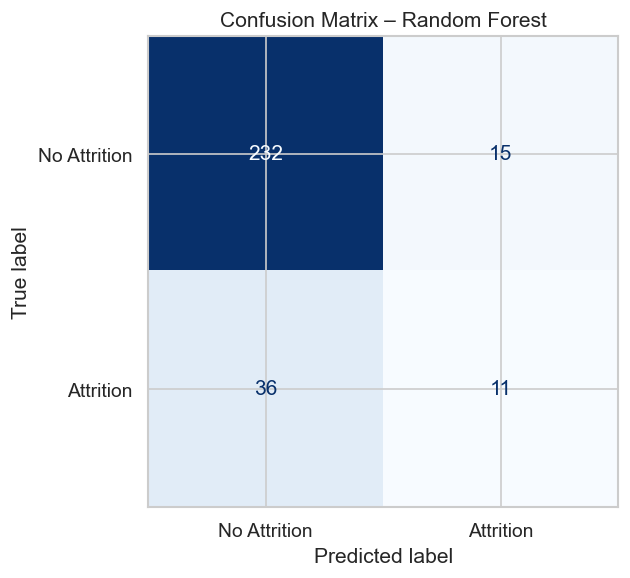

[evaluation] Figure saved to: outputs/figures\roc_random_forest.png


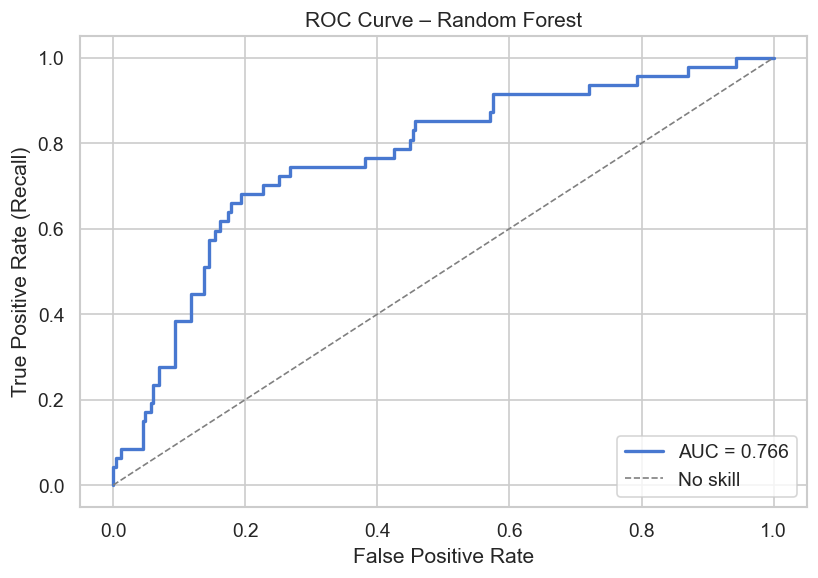

In [5]:
# ── Utvärdera tunad Random Forest ─────────────────────────────────────────────
results_tuned = evaluate_model(rf_tuned, X_test, y_test, model_name="random_forest")

plot_confusion_matrix(rf_tuned, X_test, y_test, model_name="random_forest", save=True)
plot_roc_curve(rf_tuned, X_test, y_test, model_name="random_forest", save=True)

## Vad vi ser? – Tunad Random Forest på testdata

### Metrics
| Metric   | Default | Tunad | Förändring |
|----------|---------|-------|------------|
| F1-score | 0.1429  | 0.3014 | ⬆️ +0.16 |
| ROC-AUC  | 0.7707  | 0.7659 | ➡️ i princip samma |

Tuningen mer än **fördubblade F1** – ett tydligt bevis på att
rätt hyperparametrar spelar stor roll!

### Confusion Matrix
Av de **47 anställda som faktiskt slutade** i testdatan:
- ✅ **11 hittades** (True Positives) – modellen flaggade dem korrekt
- ❌ **36 missades** (False Negatives) – modellen trodde de skulle stanna

Det ger en **Recall på 11/47 ≈ 23%** – vi missar fortfarande många riskpersoner.
Av de 15 som flaggades som "Attrition" men stannade (False Positives)
slösar HR lite onödigt tid – men det är billigare än att missa en avgång.

### ROC-kurvan
AUC = **0.766** – modellen är betydligt bättre än slumpen (0.5)
och kurvan böjer sig snyggt uppåt mot vänster, vilket är ett gott tecken.

### Slutsats
Random Forest är redan bättre än ett enskilt beslutsträd,
men Recall är fortfarande låg. Vi kommer jämföra med XGBoost i nästa notebook
för att se om boosting kan hitta fler riskpersoner.

## Steg 5 – Feature Importance

Vilka faktorer driver modellens beslut mest?

**Built-in Feature Importance** mäter hur mycket varje feature
bidrar till att minska "orenheten" i träden (Gini impurity).

Tänk på det som: *"Vilken fråga hjälper trädet mest att sortera rätt?"*

⚠️ OBS: Denna metod kan favorisera features med många unika värden.
Därför kompletterar vi med Permutation Importance i nästa steg.

[evaluation] Figure saved to: outputs/figures\fi_random_forest.png


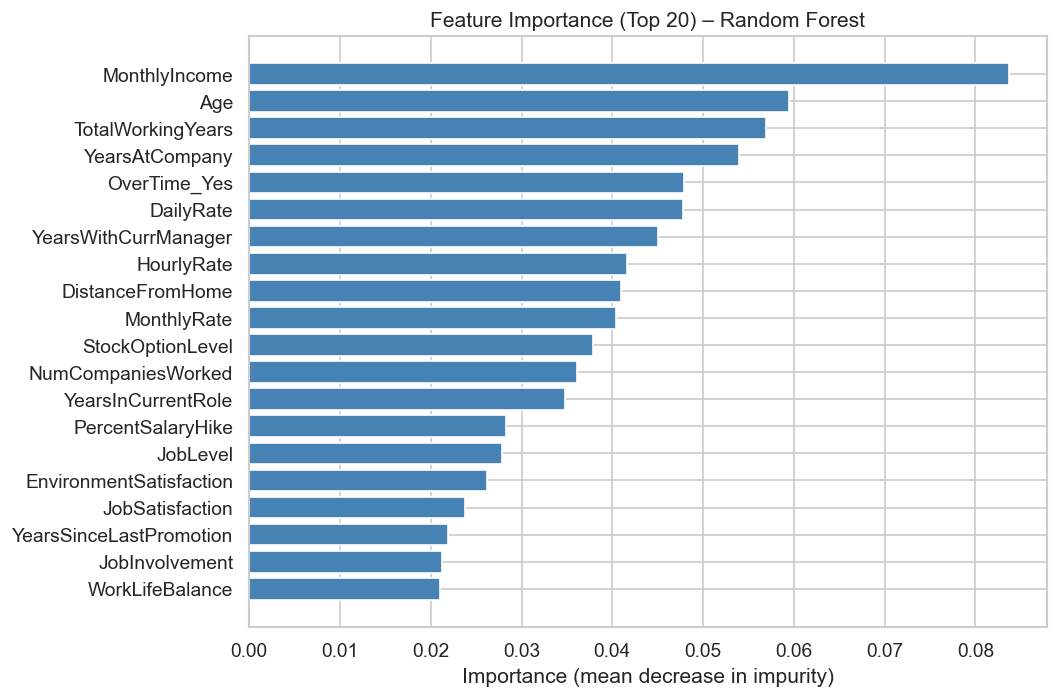

In [6]:
# ── Feature Importance ─────────────────────────────────────────────────────────
plot_feature_importance(
    rf_tuned,
    X_train.columns,
    model_name="random_forest",
    save=True,
)

## Vad vi ser? – Feature Importance (Built-in)

De viktigaste faktorerna för att förutsäga om en anställd slutar:

| Rank | Feature | Vad betyder det? |
|------|---------|-----------------|
| 🥇 1 | `MonthlyIncome` | Låg lön = högre risk att sluta |
| 🥈 2 | `Age` | Yngre anställda slutar oftare |
| 🥉 3 | `TotalWorkingYears` | Mindre erfarenhet = mer benägen att byta jobb |
| 4 | `YearsAtCompany` | Ny på jobbet = lättare att lämna |
| 5 | `OverTime_Yes` | Övertid är en stark signal för utbrändhet |

**DailyRate, HourlyRate och MonthlyRate** dyker alla upp – men dessa
är olika sätt att mäta lön och kan överlappa varandra.

⚠️ **En viktig varning:**
Built-in importance kan överskatta features med många unika värden
(t.ex. `MonthlyIncome` har hundratals olika värden).
Därför kör vi **Permutation Importance** härnäst – en mer rättvis metod!

## Steg 6 – Permutation Importance

Permutation Importance fungerar på ett smart sätt:

1. Ta en feature, t.ex. `MonthlyIncome`
2. **Blanda om dess värden slumpmässigt** – som att blanda ett kortlek
3. Kör modellen igen och mät hur mycket sämre den blir
4. Stor försämring = featuren var **viktig på riktigt**
5. Liten försämring = featuren spelar ingen större roll

Det här är mycket mer tillförlitligt än built-in importance
eftersom det testas på **testdatan** som modellen aldrig sett.

⏳ Detta tar lite längre tid – vi kör 10 upprepningar per feature!

[evaluation] Computing permutation importance for random_forest (this may take a moment)...
[evaluation] Figure saved to: outputs/figures\pi_random_forest.png


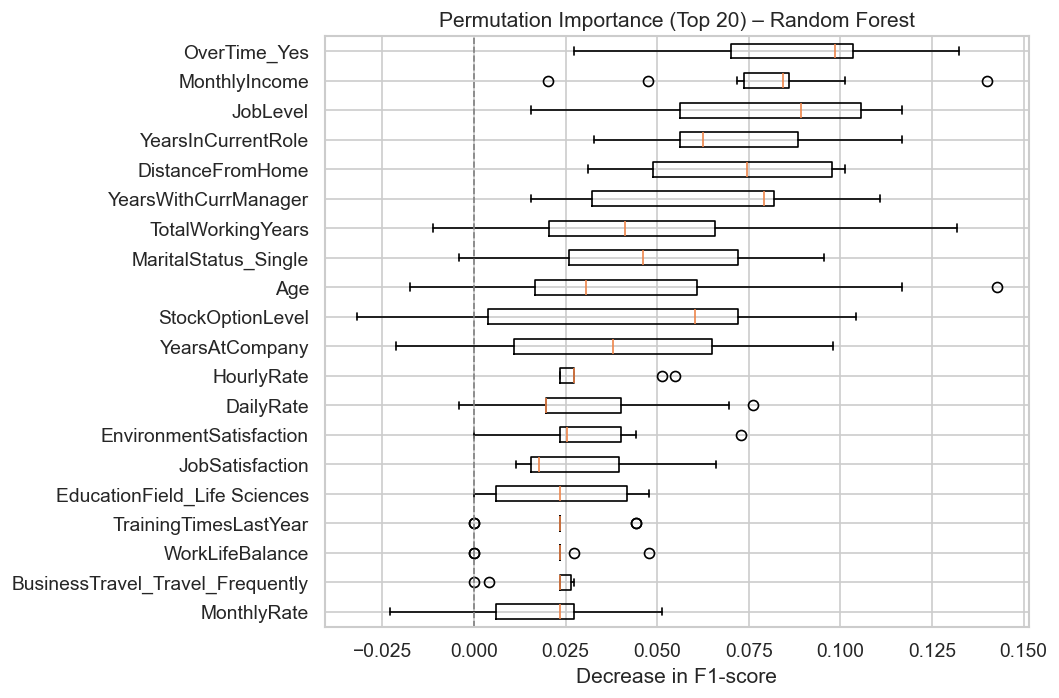

In [7]:
# ── Permutation Importance ─────────────────────────────────────────────────────
plot_permutation_importance(
    rf_tuned,
    X_test,
    y_test,
    model_name="random_forest",
    save=True,
)

## Vad vi ser? – Permutation Importance

### Jämförelse: Built-in vs Permutation Importance

| Feature | Built-in rank | Permutation rank | Förändring |
|---------|--------------|-----------------|------------|
| `OverTime_Yes` | 🥉 5 | 🥇 1 | ⬆️ Mycket viktigare än built-in trodde |
| `MonthlyIncome` | 🥇 1 | 🥈 2 | ➡️ Fortfarande viktig |
| `JobLevel` | 15 | 🥉 3 | ⬆️ Kraftigt uppgraderad |
| `DailyRate` | 6 | 13 | ⬇️ Mindre viktig än built-in trodde |
| `HourlyRate` | 8 | 12 | ⬇️ Nästan irrelevant på riktigt |

### Vad boxplotterna berättar
Varje box visar spridningen över 10 upprepningar:
- **Smal box** = stabilt och pålitligt resultat
- **Bred box** = resultatet varierar – tolka med försiktighet
- **Median nära 0** = featuren spelar liten roll för modellen

### Viktigaste lärdomar
- 🔴 **OverTime är den starkaste signalen** – jobbar du övertid
  är risken att sluta dramatiskt högre
- 💰 **MonthlyIncome bekräftas** – lön spelar verkligen roll
- 📊 **HourlyRate och DailyRate** sjunker kraftigt i ranking –
  built-in importance överskattade dem pga många unika värden
- 👤 **MaritalStatus_Single** dyker upp som ny – ensamstående
  byter jobb oftare, något built-in inte fångade lika tydligt

## Sammanfattning – Random Forest

| | Default RF | Tunad RF |
|--|-----------|---------|
| F1-score | 0.1429 | 0.3014 |
| ROC-AUC | 0.7707 | 0.7659 |

### Vad lärde vi oss?
✅ Random Forest är tydligt bättre än ett enskilt beslutsträd  
✅ GridSearchCV mer än fördubblade F1-score  
✅ OverTime, MonthlyIncome och JobLevel är de viktigaste signalerna  
⚠️ Recall är fortfarande låg – vi missar ~77% av riskpersonerna  

### Nästa steg
I **notebook 04** provar vi XGBoost – en boosting-metod som
bygger träd sekventiellt och korrigerar sina egna misstag.
Kan den hitta fler av de anställda som är på väg att sluta? 🚀